# SQL Agent

https://docs.langchain.com/oss/python/langchain/sql-agent

**SQL 에이전트의 동작 과정:**

1. 데이터베이스에서 사용 가능한 테이블과 스키마를 가져온다
2. 질문과 관련된 테이블을 결정한다
3. 관련 테이블의 스키마를 가져온다
4. 질문과 스키마 정보를 기반으로 쿼리를 생성한다
5. LLM을 사용하여 일반적인 실수가 있는지 쿼리를 재확인한다
6. 쿼리를 실행하고 결과를 반환한다
7. 쿼리가 성공할 때까지 데이터베이스 엔진에서 발생한 오류를 수정한다
8. 결과를 바탕으로 응답을 작성한다

**⚠️ 보안 경고:**

SQL 데이터베이스의 Q&A 시스템을 구축하려면 모델이 생성한 SQL 쿼리를 실행해야 한다. 이에는 내재된 위험이 있다. 데이터베이스 연결 권한이 항상 에이전트의 필요에 맞게 최대한 좁게 범위가 지정되어 있는지 확인해야 한다.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## DB설정
sqlite기반의 Chinook.db 사용
- 디지털 미디어 스토어(음원/앨범) 예제 데이터베이스로, SQL 실습용으로 많이 쓰임
- 주요 테이블 예시: Artist, Album, Track, Genre, Playlist, Customer, Invoice, InvoiceLine
- 관계 구조(대략): Artist → Album → Track, Customer → Invoice → InvoiceLine(구매내역)
- 따라서 “아티스트/앨범/트랙 조회”, “고객별 구매액 집계”, “장르별 매출”, “인보이스(주문) 분석” 같은 쿼리 연습에 적합

In [2]:
import requests
import pathlib

url = 'https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db'
local_path = pathlib.Path('Chinook.db')

response = requests.get(url) 
local_path.write_bytes(response.content)

913408

## DB 연결

In [ ]:
from langchain_community.utilities import SQLDatabase

 # SQLite 파일(Chinook.db)로 DB 연결 객체 생성
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

print(f"DB : {db.dialect}") # 연결된 DB 종류
print(f"DB Tables : {db.get_usable_table_names()}") # 사용 가능한 테이블 이름
print()

# 조회 결과 (artist 테이블 정보 5개 조회)
results = db.run('select * from artist limit 5') 
results


DB : sqlite
DB Tables : ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']



"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]"

# DB 상호작용을 위한 도구 모음

In [7]:
from langchain.chat_models import init_chat_model
from langchain_community.agent_toolkits import SQLDatabaseToolkit # DB 기반 Tools

llm = init_chat_model('gpt-5.4-mini')
toolkit = SQLDatabaseToolkit(db=db, llm=llm) # DB와 LLM 을 연결해 SQL 툴킷 생성
tools = toolkit.get_tools() # SQL 작업용 Tool 리스트

for tool in tools:
    print(f"{tool.name} : {tool.description}")


sql_db_query : Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.
sql_db_schema : Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3
sql_db_list_tables : Input is an empty string, output is a comma-separated list of tables in the database.
sql_db_query_checker : Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!


## Agent 생성
- workflow: StateGraph객체 기반으로 노드/엣지 설정. 흐름 명시
- agent: create_agent로 생성된 객체. llm/tools을 가지고, 툴선택/실행까지 직접 처리

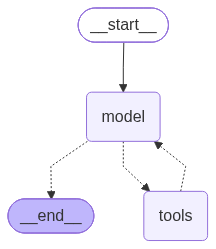

In [8]:
from langchain.agents import create_agent

system_prompt = """  # SQL 에이전트 동작 규칙(system) 프롬프트
당신은 SQL 데이터베이스와 상호작용하도록 설계된 에이전트이다.
입력 질문이 주어지면 문법적으로 올바른 실행가능한 {dialect} 쿼리를 생성한 다음 쿼리 결과를 보고 답변을 반환한다.
사용자가 특정 개수의 레코드를 얻고자 하는 경우를 제외하고는 항상 쿼리를 최대 {top_k}개의 결과로 제한한다.

관련 열을 기준으로 결과를 정렬하여 데이터베이스에서 가장 흥미로운 레코드를 반환할 수 있다.
특정 테이블의 모든 열을 쿼리하지 말고 질문과 관련된 열만 요청한다.

쿼리를 실행하기 전에 반드시 쿼리를 재확인해야 한다.
쿼리를 실행하는 동안 오류가 발생하면 쿼리를 다시 작성하고 재시도한다.

**데이터베이스에 대한 DML 문(INSERT, UPDATE, DELETE, DROP 등)을 작성하지 않는다.**

시작할 때는 항상 데이터베이스의 테이블을 확인하여 쿼리할 수 있는 내용을 확인해야 한다.
이 단계를 건너뛰지 않는다.

그런 다음 가장 관련성이 높은 테이블의 스키마를 쿼리해야 한다.
""".format(dialect=db.dialect, top_k=5)  # DB별 문법 / 조회 제한 개수를 프롬프트에 주입

agent = create_agent(llm, tools, system_prompt=system_prompt)
agent

# Agent 실행

In [ ]:
question = "최신 앨범/아티스트를 조회해줘"

print(f'Question : {question}')

for step in agent.stream({
    'messages': [('human', question)]
}, stream_mode='values'): # 중간중간 단계를 모두 출력
    step['messages'][-1].pretty_print()



Question : 최신 앨범/아티스트를 조회해줘
================================ Human Message =================================

최신 앨범/아티스트를 조회해줘
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_mWTkJXGfWdfHbS1cQxMFbfKU)
 Call ID: call_mWTkJXGfWdfHbS1cQxMFbfKU
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_2OMDeqkiB0tPEvHJ9ENgXN6k)
 Call ID: call_2OMDeqkiB0tPEvHJ9ENgXN6k
  Args:
    table_names: Album, Artist
  sql_db_query_checker (call_P1IKQJcHdK7TH6mYvYGj1ksP)
 Call ID: call_P1IKQJcHdK7TH6mYvYGj1ksP
  Args:
    query: SELECT a.Title AS album_title, ar.Name AS artist_name, a.AlbumId
FROM Album a
JOIN Artist ar ON a.ArtistId = ar.ArtistId
ORDER BY a.

In [10]:
question = '평균적으로 가장 긴 트랙을 가지는 장르는'

print(f'Question : {question}')

for step in agent.stream({
    'messages': [('human', question)]
}, stream_mode='values'): # 중간중간 단계를 모두 출력
    step['messages'][-1].pretty_print()


Question : 평균적으로 가장 긴 트랙을 가지는 장르는
================================ Human Message =================================

평균적으로 가장 긴 트랙을 가지는 장르는
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_84n7SlQemrhHV7lofufgPAkg)
 Call ID: call_84n7SlQemrhHV7lofufgPAkg
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_BocToZPEVMNOdQQ0nX74nVdm)
 Call ID: call_BocToZPEVMNOdQQ0nX74nVdm
  Args:
    table_names: Genre, Track
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Genre" (
	"GenreId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("GenreId")
)

/*
3 rows from Genre table:

## Human-in-the-loop
- Middleware를 통한 HITL 구현

In [13]:
# 도구 실행 전 대기/승인 미들웨어
from langchain.agents.middleware import HumanInTheLoopMiddleware
# 실행 상태 저장하는 메모리 저장소 
from langgraph.checkpoint.memory import InMemorySaver 

agent_with_hitl = create_agent(
    llm,
    tools,
    system_prompt=system_prompt,
    middleware=[
        # 에이전트 실행 중 개입 로직 추가 미들웨어
        HumanInTheLoopMiddleware(
            {'sql_db_query': True}, # sql_db_query 실행 직전에 중단 (승인 요청)
            description_prefix = '[도구 실행 승인 대기중]' # 중단시 문구
        )
    ],
    checkpointer=InMemorySaver() # 상태 저장소
)

In [ ]:
# HITL 에이전트를 Stream 방식으로 실행하면서 sql_db_query 실행 전 중단/승인을 받음
question = '평균적으로 가장 긴 트랙을 가지는 장르는'

config = {'configurable': {'thread_id' : 1}} # 체크포인트 저장용 thread_id 설정

for step in agent_with_hitl.stream({'messages': [('human'), question]}, stream_mode='values', config=config):
    if '__interrupt__' in step: # 도구 실행 중 중단 이벤트에 걸린 경우
        print('에이전트 실행이 중단되었습니다. 관리자 승인을 기다리는 중...')

        interrupt = step['__interrupt__'][0] # 발생한 interrupt 이벤트
        for request in interrupt.value['action_requests']: # 승인 대기중인 도구 호출 요청들
            print(f"도구 : {request['name']}")
            print(f"인자 : {request['args']}")
            print(f"설명 : {request['description']}")

    elif 'messages' in step: # 일반적인 메시지 업데이트가 있으면
        step['messages'][-1].pretty_print()
    else:
        pass

================================ Human Message =================================

평균적으로 가장 긴 트랙을 가지는 장르는
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_O5lxJmLxx9Z4eR1RZriSSBf2)
 Call ID: call_O5lxJmLxx9Z4eR1RZriSSBf2
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_eYUplEeqMkhcqBKq2PTZ3Nm3)
 Call ID: call_eYUplEeqMkhcqBKq2PTZ3Nm3
  Args:
    table_names: Genre, Track
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Genre" (
	"GenreId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("GenreId")
)

/*
3 rows from Genre table:
GenreId	Name
1	Rock
2	Jazz
3	Meta

In [ ]:
from langgraph.types import Command

# 도구 실행 요청 승인하면서 재개
command = Command(resume={'decisions': [{'type': 'approve'}]})

for step in agent_with_hitl.stream(command, stream_mode='values',config=config):
    if '__interrupt__' in step: # 도구 실행 중 중단 이벤트에 걸린 경우
        print('에이전트 실행이 중단되었습니다. 관리자 승인을 기다리는 중...')

        interrupt = step['__interrupt__'][0] # 발생한 interrupt 이벤트
        for request in interrupt.value['action_requests']: # 승인 대기중인 도구 호출 요청들
            print(f"도구 : {request['name']}")
            print(f"인자 : {request['args']}")
            print(f"설명 : {request['description']}")

    elif 'messages' in step: # 일반적인 메시지 업데이트가 있으면
        step['messages'][-1].pretty_print()
    else:
        pass


================================== Ai Message ==================================
Tool Calls:
  sql_db_query (call_LdL6mywYmnH71ihQOS6xnZSB)
 Call ID: call_LdL6mywYmnH71ihQOS6xnZSB
  Args:
    query: SELECT g.Name AS Genre, AVG(t.Milliseconds) AS AvgMilliseconds
FROM Track t
JOIN Genre g ON t.GenreId = g.GenreId
GROUP BY g.GenreId, g.Name
ORDER BY AvgMilliseconds DESC
LIMIT 5;
================================== Ai Message ==================================
Tool Calls:
  sql_db_query (call_LdL6mywYmnH71ihQOS6xnZSB)
 Call ID: call_LdL6mywYmnH71ihQOS6xnZSB
  Args:
    query: SELECT g.Name AS Genre, AVG(t.Milliseconds) AS AvgMilliseconds
FROM Track t
JOIN Genre g ON t.GenreId = g.GenreId
GROUP BY g.GenreId, g.Name
ORDER BY AvgMilliseconds DESC
LIMIT 5;
================================= Tool Message =================================
Name: sql_db_query

[('Sci Fi & Fantasy', 2911783.0384615385), ('Science Fiction', 2625549.076923077), ('Drama', 2575283.78125), ('TV Shows', 2145041.0215053763)